# **Uber Drive Data Analysis using Python**


### **INTRODUCTION**

This project focuses on analyzing **Uber Drive trip data using Python** to understand travel patterns and user behavior. The dataset contains information about trip dates and times, trip categories, starting and stopping locations, travel distance, and trip purposes.
The project applies **data cleaning, feature engineering, exploratory data analysis (EDA), and data visualization** techniques to transform raw trip data into meaningful insights. The analysis explores trip frequency, travel distance, trip duration, popular routes, trip purposes, time-of-day patterns, and monthly travel trends.

### **OBJECTIVES**

- Analyze Uber Drive trip data.
- Clean and preprocess the dataset.
- Identify travel patterns.
- Visualize the data.
- Generate business insights.

### **IMPORT LIBRARIES**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### **LOAD DATASET**

In [5]:
df = pd.read_csv('uberdrive (1).csv')
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [3]:
df.tail(5)

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


### **UNDERSTANDING THE DATASET**

In [4]:
df.shape,df.size

((1156, 7), 8092)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [6]:
df.describe(include='object')

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,PURPOSE*
count,1156,1155,1155,1155,1155,653
unique,1155,1154,2,177,188,10
top,6/28/2016 23:34,6/28/2016 23:59,Business,Cary,Cary,Meeting
freq,2,2,1078,201,203,187


### **DATA CLEANING & TRANSFORMATUIN** 

In [6]:
df.drop(df.index[-1],inplace=True)

In [7]:
df['START*'] = df['START*'].replace('Kar?chi','Karachi')

In [8]:
df['PURPOSE*'].fillna('UNKNOWN', inplace=True)

In [9]:
df.drop_duplicates(inplace=True)


In [10]:
df['START_DATE*'] = pd.to_datetime(df['START_DATE*'], format='mixed', errors='coerce')
df['END_DATE*'] = pd.to_datetime(df['END_DATE*'], format='mixed', errors='coerce')

### **FEATURE ENGINEERING**

In [11]:
from datetime import datetime
df['DATE'] = pd.DatetimeIndex(df['START_DATE*']).date
df['TIME'] = pd.DatetimeIndex(df['START_DATE*']).hour
df['DAY-NIGHT'] = pd.cut(x = df['TIME'], bins = (-1,6,12,17,23), labels=['Early Morning', 'Morning', 'Afternoon', 'Evening'])

df['MONTH'] = pd.DatetimeIndex(df['START_DATE*']).month
dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['MONTH'] = df['MONTH'].map(dict)

df['MINUTES'] = (df['END_DATE*'] - df['START_DATE*']).dt.total_seconds() / 60
df['DAY'] = df['START_DATE*'].dt.day_name()

In [12]:
def round_trip(x):
  if x['START*'] == x['STOP*']:
     return 'Yes'
  else:
     return 'No'
df['ROUNDTRIP'] = df.apply(round_trip, axis=1)


### **EXPLORATORY DATA ANALYSIS(EDA)** 

#### **1. Univariate analysis**

Examine the distribution of **ride category, purpose, day/night period, and round-trip status**.

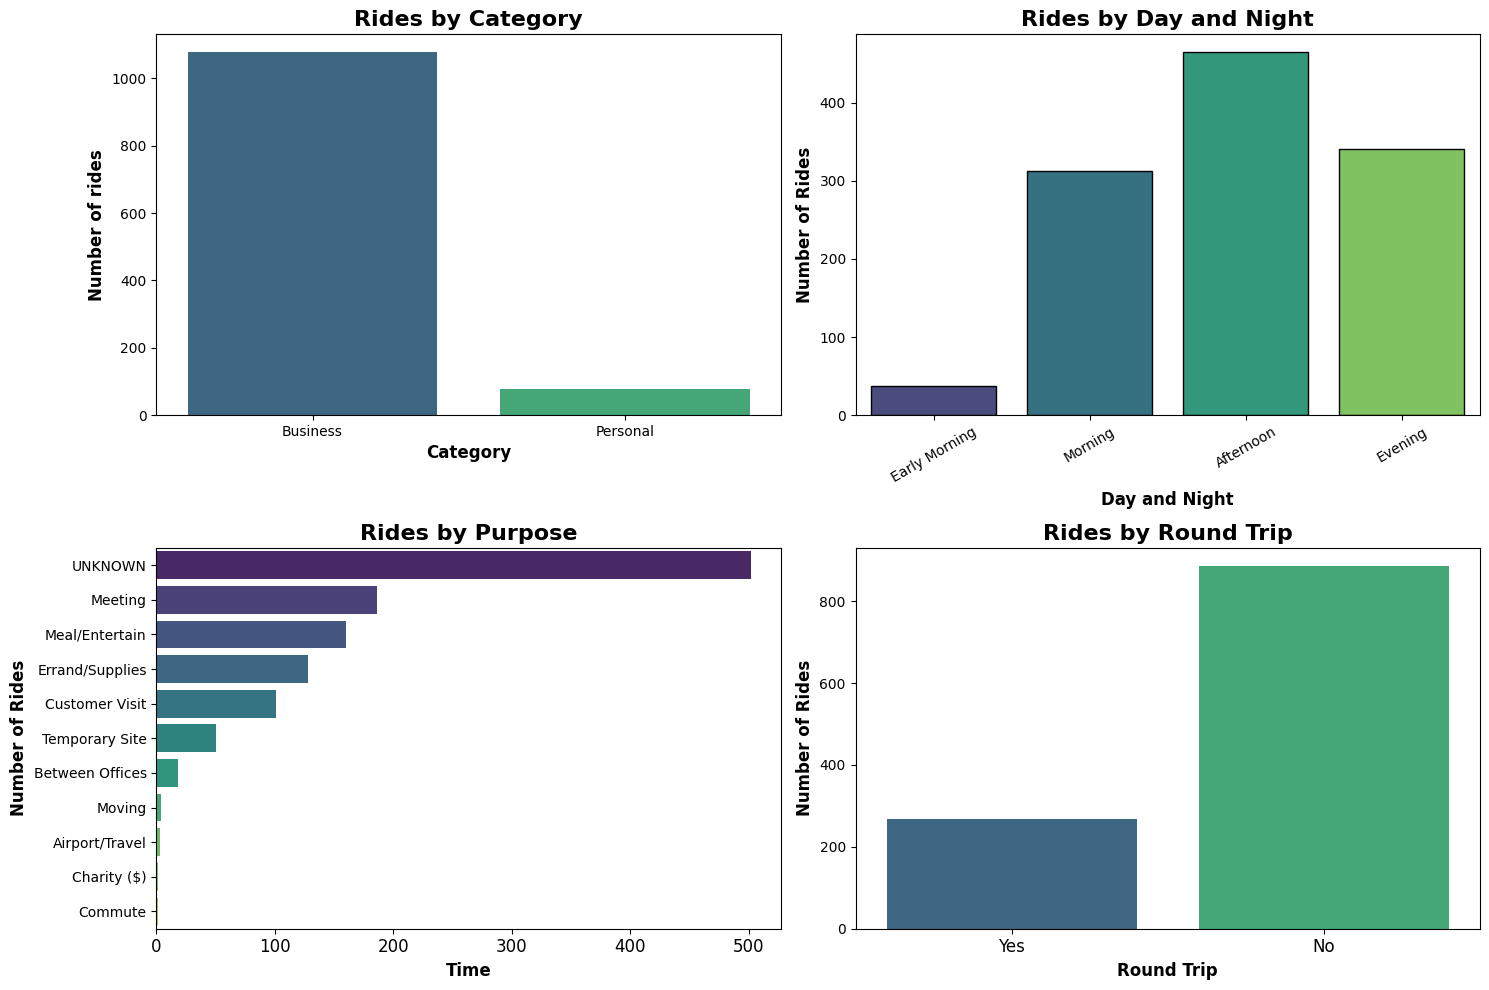

In [59]:
plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
sns.countplot(x='CATEGORY*', data=df, palette='viridis')
plt.title('Rides by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of rides', fontsize=12, fontweight='bold')

plt.subplot(2,2,2)
sns.countplot(data=df,x='DAY-NIGHT',palette='viridis', edgecolor='black')
plt.xticks(rotation=30)
plt.title('Rides by Day and Night', fontsize=16, fontweight='bold')
plt.xlabel('Day and Night', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')

plt.subplot(2,2,3)
sns.countplot(y='PURPOSE*',order=df['PURPOSE*'].value_counts().index,data=df,palette='viridis')
plt.xticks(fontsize=12)
plt.title('Rides by Purpose', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')

plt.subplot(2,2,4)
sns.countplot(x='ROUNDTRIP', data=df, palette='viridis')
plt.xticks(fontsize=12)
plt.xlabel('Round Trip', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')
plt.title('Rides by Round Trip', fontsize=16, fontweight='bold')


plt.tight_layout()
plt.show()

**Insight:** Business rides dominate over Personal, most trips happen during the Afternoon/Evening, and only a small share are round trips.

#### **2. Bivariate Analysis**

Check the relationship between **ride distance and ride duration**.

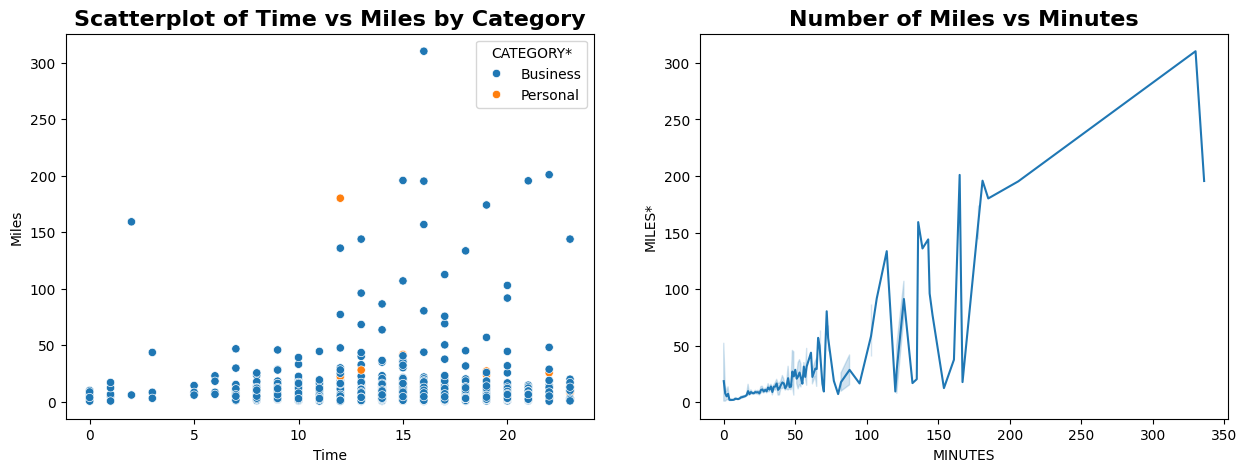

In [49]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.scatterplot(data = df , x = 'TIME', y = 'MILES*', hue= 'CATEGORY*')
plt.title('Scatterplot of Time vs Miles by Category',fontsize=16, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Miles')

plt.subplot(1,2,2)
sns.lineplot(data = df,x = df['MINUTES'],y = df['MILES*'])
plt.title('Number of Miles vs Minutes',fontsize=16, fontweight='bold')
plt.show()

**Insight:** Trip distance doesn't show a strong dependency on time of day or duration — most rides stay under a moderate mileage regardless of when they happen.

#### **3. Multivariate Analysis**

Understand how ride purposes are distributed across different time periods.

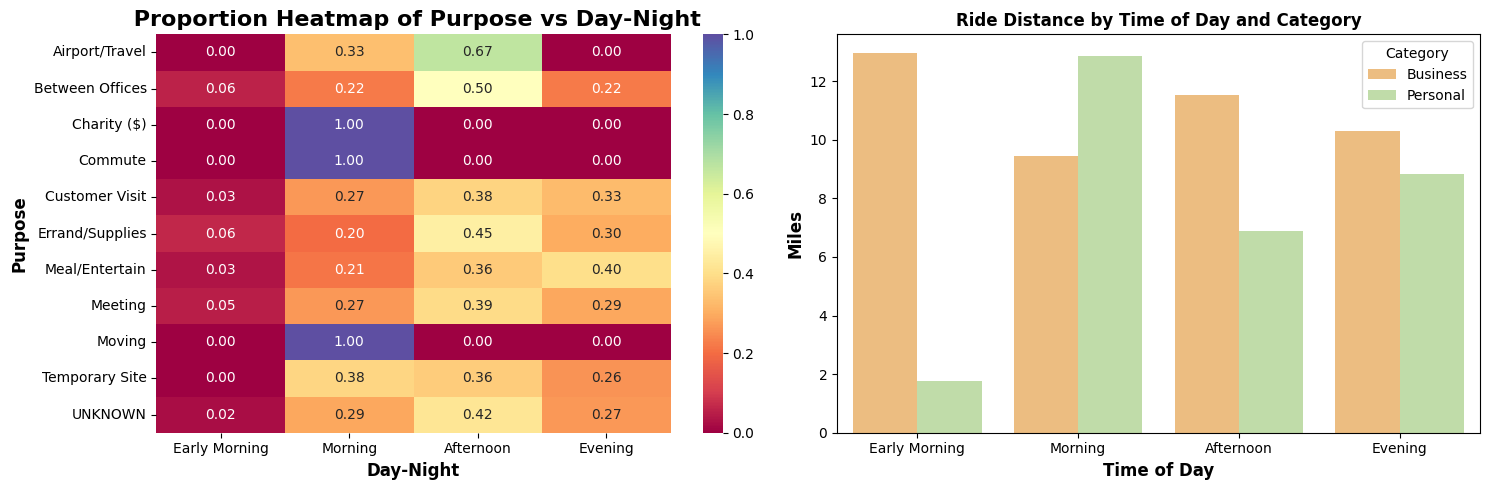

In [68]:
plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
heatmap_data = df.groupby(['PURPOSE*', 'DAY-NIGHT']).size().unstack()
heatmap_data = heatmap_data.div(heatmap_data.sum(axis = 1), axis=0)
sns.heatmap(heatmap_data, cmap='Spectral', annot=True, fmt='.2f')
plt.title(' Proportion Heatmap of Purpose vs Day-Night',fontsize=16, fontweight='bold')
plt.xlabel('Day-Night',fontsize=12, fontweight='bold')
plt.ylabel('Purpose',fontsize=12, fontweight='bold')

plt.subplot(1,2,2)
plt.Figure(figsize=(12,5))
sns.barplot(data=df,x='DAY-NIGHT', y='MILES*', hue='CATEGORY*', ci=None, palette='Spectral')
plt.title('Ride Distance by Time of Day and Category',fontsize=12, fontweight='bold')
plt.xlabel('Time of Day',fontsize=12, fontweight='bold')
plt.ylabel('Miles',fontsize=12, fontweight='bold')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

**Insight:** Meetings cluster heavily in the Morning/Afternoon, while Meal/Entertain purposes skew toward Evening — purpose and time of day are clearly linked.

#### **4; Business Questions**

#### **Are there More Rides  on Weekdays or weekends?**

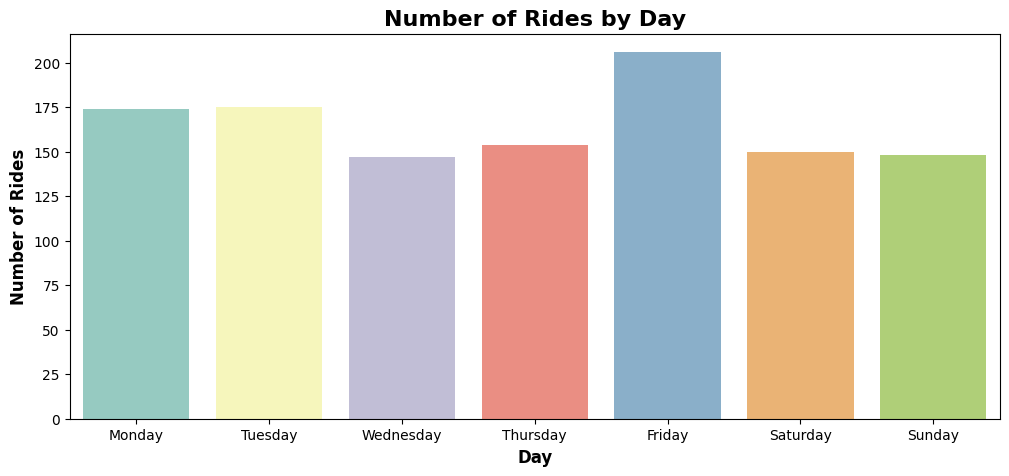

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data = df , x = 'DAY' ,order = ['Monday','Tuesday','Wednesday' ,'Thursday' ,'Friday' ,'Saturday','Sunday'], palette='Set3')
plt.title('Number of Rides by Day',fontsize=16, fontweight='bold')
plt.xlabel('Day',fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides',fontsize=12, fontweight='bold')
plt.show()

**Insight:** Weekdays see more rides than weekends, consistent with work-related travel (Meetings, Commute) driving overall volume.

#### **How does the Rides Count Change Across Different months?**

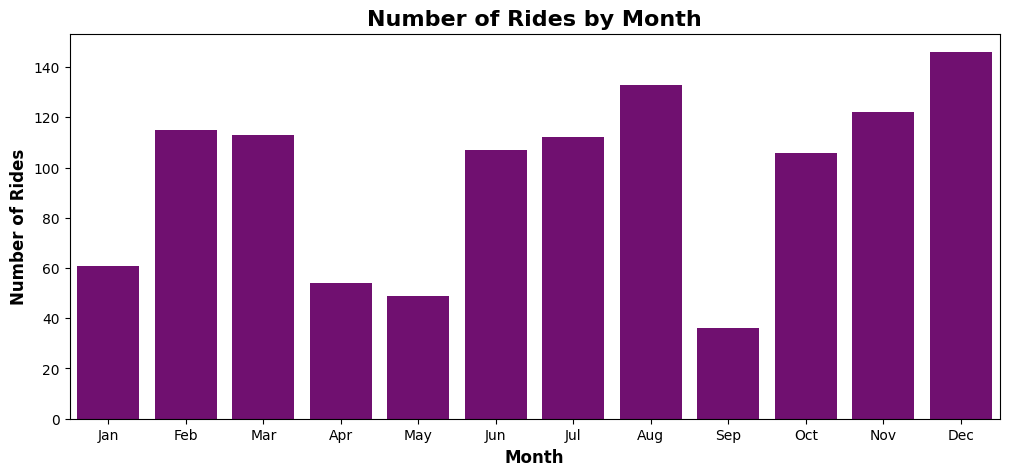

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data = df, x = 'MONTH',color='purple')
plt.title('Number of Rides by Month',fontsize=16, fontweight='bold')
plt.xlabel('Month',fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides',fontsize=12, fontweight='bold')
plt.show()

**Insight:** Ride volume varies noticeably across months, indicating seasonal or work-cycle-driven demand rather than flat, consistent usage.

#### **Which Starting Location is the Highest Number of Rides?**

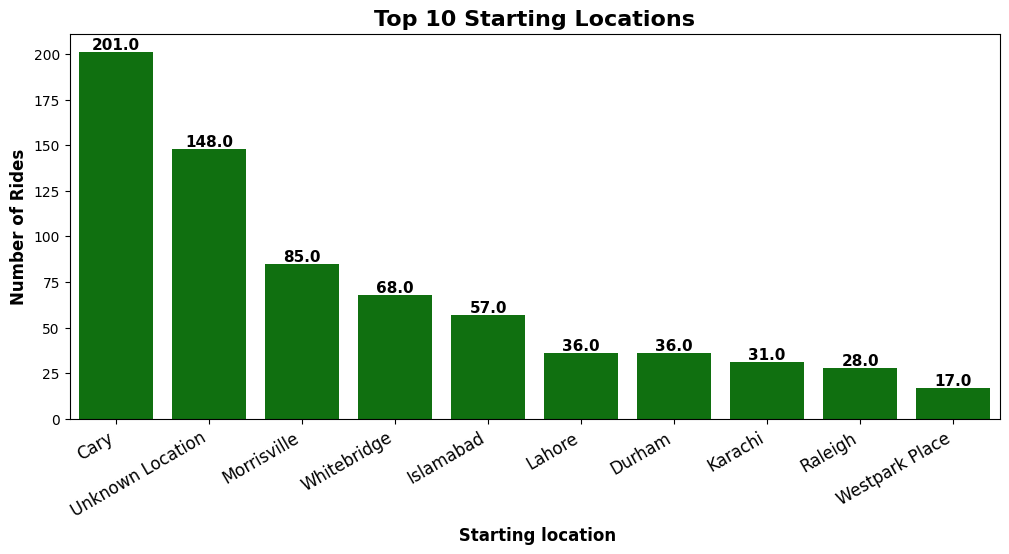

In [ ]:
plt.figure(figsize=(12, 5))
top_start_locations = df['START*'].value_counts().head(10)
ax = sns.countplot(x ='START*', order=top_start_locations.index, data=df, color='green')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() /2., p.get_height()), ha = 'center', va = 'center',xytext = (0, 5), textcoords = 'offset points',fontsize=11,
        fontweight='bold')

plt.xticks(rotation=30, ha= 'right', fontsize = 12)
plt.title('Top 10 Starting Locations', fontsize=16, fontweight='bold')
plt.xlabel(' Starting location',fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides',fontsize=12, fontweight='bold')
plt.show()

**Insight:** A small number of locations account for a disproportionate share of trips — suggesting a few hubs (likely home/office) anchor most travel.

#### **What are the Busiest Time of Day for time?**

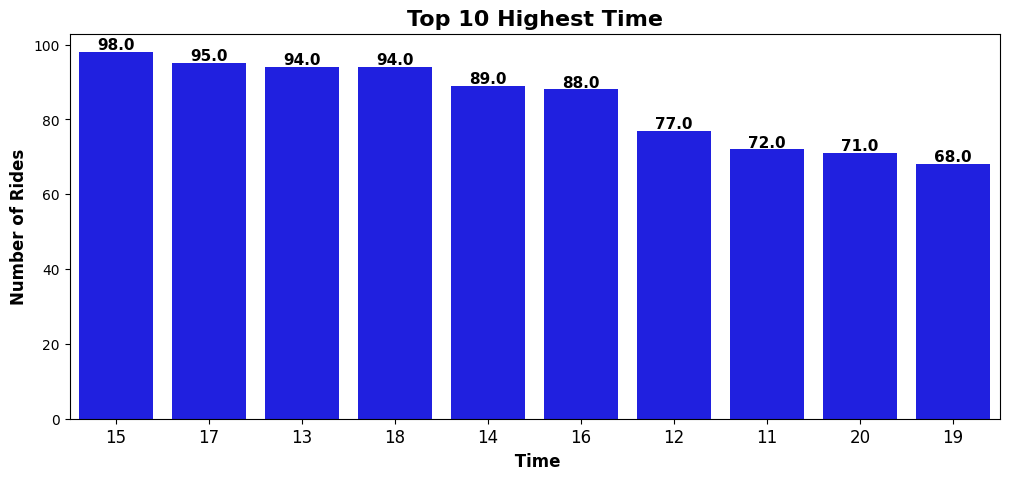

In [ ]:
plt.figure(figsize=(12, 5))
top_start_locations = df['TIME'].value_counts().head(10)
ax = sns.countplot(x ='TIME', order=top_start_locations.index, data=df, color='blue')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() /2., p.get_height()), ha = 'center', va = 'center',xytext = (0, 5), textcoords = 'offset points',fontsize=11,
        fontweight='bold')
plt.xticks(fontsize = 12)
plt.title('Top 10 Highest Time',fontsize=16, fontweight='bold')
plt.xlabel(' Time',fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides',fontsize=12, fontweight='bold')
plt.show()

#### **What is the Top 5 Most Common Purpose?**

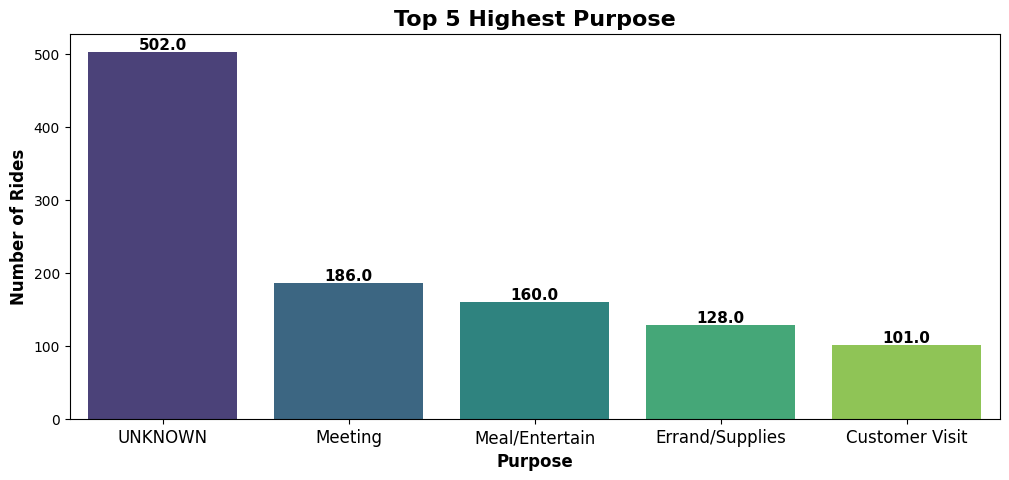

In [71]:
plt.figure(figsize=(12, 5))
top_purpose = df['PURPOSE*'].value_counts().head(5)
ax = sns.countplot(x ='PURPOSE*', order=top_purpose.index, data=df, palette='viridis')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() /2., p.get_height()), ha = 'center', va = 'center',xytext = (0, 5), textcoords = 'offset points',fontsize=11,
        fontweight='bold')
plt.xticks(fontsize = 12)
plt.title('Top 5 Highest Purpose',fontsize=16, fontweight='bold')
plt.xlabel('Purpose',fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides',fontsize=12, fontweight='bold')
plt.show()

#### **How Many Rides ware Roundtrips?**

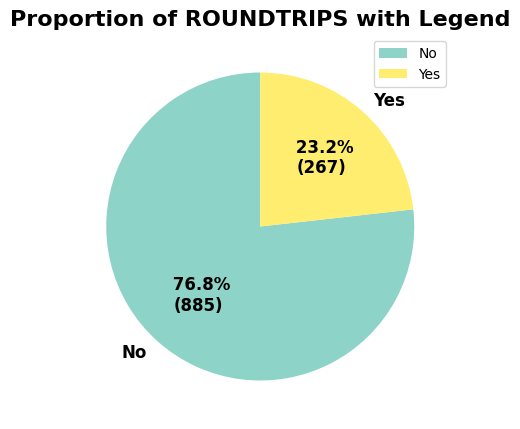

In [70]:
plt.figure(figsize=(10, 5))
def autopct_with_counts(pct, values):
    total = sum(values)
    absolute = int(pct/100.*total)
    return f'{pct: .1f}%\n({absolute})'
df['ROUNDTRIP'].value_counts().plot.pie(
    autopct=lambda pct: autopct_with_counts(pct, df['ROUNDTRIP'].value_counts()), startangle=90, cmap='Set3',textprops={'color':'black','fontsize':12,'fontweight':'bold'})
plt.title('Proportion of ROUNDTRIPS with Legend',fontsize=16, fontweight='bold')
plt.ylabel('')
plt.legend(labels=df['ROUNDTRIP'].value_counts().index, loc='upper right')
plt.show()


**Insight:** Roughly 1 in 4 trips is a round trip, most likely errands or short local visits rather than one-way commutes.

#### **What are the Largest and Shortest Ride Duration for each Category?**

In [ ]:
pd.DataFrame({
    'Min': df.groupby('CATEGORY*')['MINUTES'].min(),
    'Max': df.groupby('CATEGORY*')['MINUTES'].max()
})

,Min,Max
CATEGORY*,,
Business,0.0,336.0
Personal,4.0,185.0


#### **What is the Common combination of start and Stop and How many Times Does the Combination Appears in the Dataset?**

In [ ]:
df.groupby(['START*', 'STOP*']).size().sort_values(ascending = False).head(3)

START*            STOP*           
Unknown Location  Unknown Location    86
Morrisville       Cary                75
Cary              Morrisville         67
dtype: int64

#### **What is the Average Time Different Between the Start of the first Ride and Start of the next Ride For each Unique Day?**

In [ ]:
df = df.sort_values('START_DATE*')
df['next_ride'] = df['START_DATE*'].shift(-1)
df['time_diff'] = (df['next_ride'] - df['START_DATE*']).dt.total_seconds() / 60
ave_time_diff = df.groupby('DATE')['time_diff'].mean()
print(ave_time_diff)

DATE
2016-01-01     254.000000
2016-01-02    2643.000000
2016-01-05    1271.000000
2016-01-06     455.000000
2016-01-07    3998.000000
                 ...     
2016-12-27     255.333333
2016-12-28     139.285714
2016-12-29     154.307692
2016-12-30     178.400000
2016-12-31     315.250000
Name: time_diff, Length: 294, dtype: float64


### **CONCLUSION**

The Uber Drive dataset contained **1,155 trip records** after removing the totals row. The analysis showed several important patterns in trip purposes, travel distance, duration, time periods, and routes.

Among the recorded trip purposes, **Meeting was the most common identified purpose with 187 rides**, followed by **Meal/Entertain with 160 rides** and **Errand/Supplies with 128 rides**. However, **502 rides had an unknown purpose**, indicating that missing purpose information is an important data-quality limitation in the dataset.

Monthly analysis showed that **October had the highest total travel distance at 1,810 miles**, while **May had the lowest at 363.8 miles**. The average trip distance was highest during the **Early Morning period at approximately 12.35 miles**, followed by the Afternoon period at 11.25 miles.

The analysis also identified **288 trips where the starting and stopping locations were the same**, with an average distance of approximately **7.74 miles**. The most frequently occurring meaningful routes were **Morrisville → Cary with 75 trips** and **Cary → Morrisville with 67 trips**. **Unknown Location → Unknown Location** was the most frequent overall combination with 86 trips, but this is less useful for route analysis because the locations are unavailable.

Trip-duration analysis showed that the **Business category had a maximum recorded duration of 336 minutes**, while the Personal category had a maximum of 185 minutes. Among trip purposes, **Commute had the highest average duration at 185 minutes**, followed by Customer Visit at approximately 33.42 minutes and Meeting at approximately 29.74 minutes.

Overall, the analysis demonstrates how **Python, Pandas, Matplotlib, and Seaborn** can be used to clean raw trip data, engineer meaningful features, explore travel behavior, and generate business-oriented insights. The findings can help identify frequently used routes, high-travel periods, common trip purposes, and areas where better data collection could improve future analysis.
